# Bled: gradient matching on the first half, forecast on the second

Fits the phyto.conc equation ProBMoT's own exhaustive search picked (Model #939,
`bled_model.py` - hand-derived from the ProBMoT process templates, not PyBM) using
`odestimate.gradient_matching` on only the FIRST HALF of one Bled season (`96.data`),
then forward-simulates (`scipy.integrate.solve_ivp`) over the WHOLE season and plots
against all the real data - the second half is a genuine forecast, not something the
fit ever saw.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

from bled_model import PROBMOT_THETA, THETA_NAMES, load_bled, make_f, make_scipy_rhs
from odestimate.gradient_matching import gradient_matching

In [2]:
t, phyto, temp, light, daph = load_bled("data/96.data")

split = len(t) // 3
t_train, phyto_train = t[:split], phyto[:split]
print(f"{len(t)} days total, training on the first {split} ({t_train[0]:.0f}-{t_train[-1]:.0f}), forecasting {t[-1]-t_train[-1]:.0f} days beyond that")

327 days total, training on the first 109 (0-108), forecasting 218 days beyond that


## Fit on the training half only

`temp`/`light`/`daph` (the exogenous drivers) are read directly at the training times -
no interpolation needed here (see `bled_model.make_f`'s own docstring for why gradient
matching specifically can't interpolate on the fly - `jacfwd` forbids it).

In [3]:
f_train = make_f(
    torch.as_tensor(temp[:split]), torch.as_tensor(light[:split]), torch.as_tensor(daph[:split])
)
result = gradient_matching(t_train, phyto_train[None, :], f_train, theta_0=PROBMOT_THETA)

print("success:", result.success, " cost:", result.cost)
for name, probmot_val, fitted_val in zip(THETA_NAMES, PROBMOT_THETA, result.x):
    print(f"  {name:<18} probmot={probmot_val:<12.4g} fitted={fitted_val:<12.4g}")

success: False  cost: 0.15159362358410486
  maxGrowthRate      probmot=0.6516       fitted=0.2857      
  refTempGrowth      probmot=22           fitted=24.82       
  optLight           probmot=140.4        fitted=99.78       
  respRate           probmot=0.006043     fitted=-0.002165   
  maxFiltrationRate  probmot=15           fitted=23.81       
  refTempDaph        probmot=12.09        fitted=0.001743    
  halfSaturation     probmot=20           fitted=8.689e+05   


## Forward-simulate over the WHOLE season and plot

The drivers are known for the whole season regardless (they're exogenous, never fit) -
only `phyto`'s own second half is held out from the fit above.

In [4]:
temp_i = interp1d(t, temp, fill_value="extrapolate")
light_i = interp1d(t, light, fill_value="extrapolate")
daph_i = interp1d(t, daph, fill_value="extrapolate")
rhs = make_scipy_rhs(temp_i, light_i, daph_i, result.x)

sol = solve_ivp(rhs, (t[0], t[-1]), [phyto[0]], t_eval=np.linspace(t[0], t[-1], 500))
print("solve_ivp success:", sol.success)

solve_ivp success: True


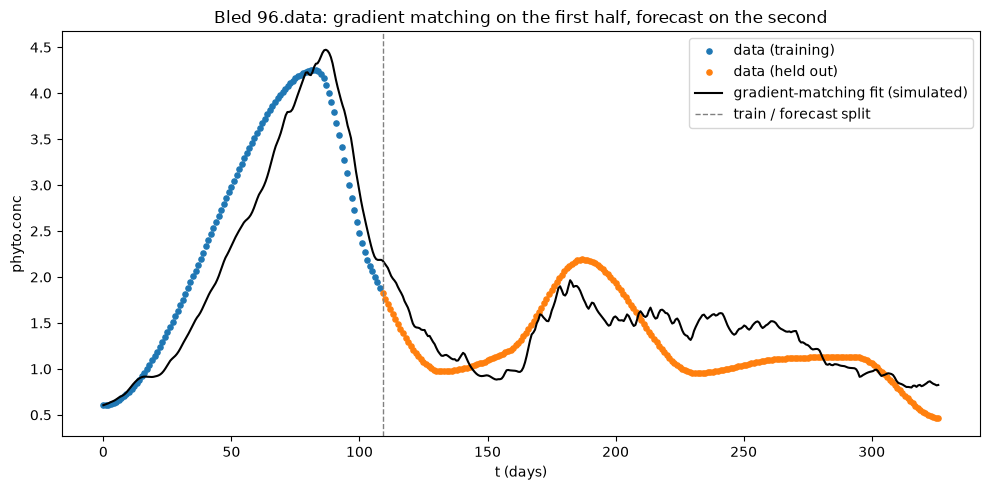

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(t[:split], phyto[:split], s=14, color="tab:blue", label="data (training)")
ax.scatter(t[split:], phyto[split:], s=14, color="tab:orange", label="data (held out)")
ax.plot(sol.t, sol.y[0], color="black", lw=1.5, label="gradient-matching fit (simulated)")
ax.axvline(t[split], color="gray", ls="--", lw=1, label="train / forecast split")

ax.set_xlabel("t (days)")
ax.set_ylabel("phyto.conc")
ax.set_title("Bled 96.data: gradient matching on the first half, forecast on the second")
ax.legend()
fig.tight_layout()

## Interactive exploration

One slider per constant (range = the same `<lo,hi>` ProBMoT's own library, `AquaticEcosystem.pbl`,
declares for that process type) plus a `t_max` slider to shrink the integration interval (e.g. to
quickly preview just the first N days instead of always solving the whole season). No streaming/
incremental redraw within a single `solve_ivp` call - not needed here (a single solve of this
1-state, ~300-day ODE is already near-instant); `continuous_update=False` on every slider so a
redraw only happens once you release it, not on every pixel of drag.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Same <lo,hi> ranges ProBMoT's own library (AquaticEcosystem.pbl) declares for each process type -
# see bled_model.py's own module docstring for which process each constant comes from.
SLIDER_RANGES = {
    "maxGrowthRate": (0.05, 3.0),
    "refTempGrowth": (10.0, 22.0),
    "optLight": (100.0, 200.0),
    "respRate": (0.0001, 1.0),
    "maxFiltrationRate": (0.01, 15.0),
    "refTempDaph": (10.0, 22.0),
    "halfSaturation": (0.0, 20.0),
}

t_max_slider = widgets.FloatSlider(
    value=float(t[-1]), min=float(t[10]), max=float(t[-1]), step=1.0,
    description="t_max", continuous_update=False, layout=widgets.Layout(width="500px"),
)
theta_sliders = {
    name: widgets.FloatSlider(
        value=float(val), min=lo, max=hi, step=(hi - lo) / 200, description=name,
        continuous_update=False, layout=widgets.Layout(width="500px"), style={"description_width": "120px"},
    )
    for name, val, (lo, hi) in zip(THETA_NAMES, PROBMOT_THETA, (SLIDER_RANGES[n] for n in THETA_NAMES))
}


def _simulate_and_plot(t_max, **theta_kwargs):
    theta = np.array([theta_kwargs[name] for name in THETA_NAMES])
    rhs = make_scipy_rhs(temp_i, light_i, daph_i, theta)
    sol = solve_ivp(rhs, (t[0], t_max), [phyto[0]], t_eval=np.linspace(t[0], t_max, 300))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(t, phyto, s=10, color="tab:blue", label="data")
    if sol.success:
        ax.plot(sol.t, sol.y[0], color="black", lw=1.5, label="simulated")
    else:
        ax.text(0.5, 0.5, "solve_ivp failed", transform=ax.transAxes, ha="center", color="tab:red")
    ax.axvline(t_max, color="gray", ls="--", lw=1)
    ax.set_xlim(t[0], t[-1])
    ax.set_xlabel("t (days)")
    ax.set_ylabel("phyto.conc")
    ax.legend()
    fig.tight_layout()
    plt.show()


display(widgets.interactive(_simulate_and_plot, t_max=t_max_slider, **theta_sliders))

interactive(children=(FloatSlider(value=326.0, continuous_update=False, description='t_max', layout=Layout(wid…